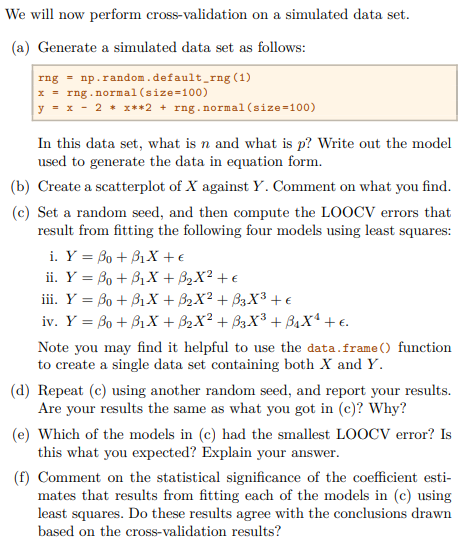

=== Part (a) ===
n (number of observations) = 100
p (number of predictors) = 1 (just X)
Model used to generate data: Y = X - 2X² + ε
where ε ~ N(0,1)

=== Part (b) ===


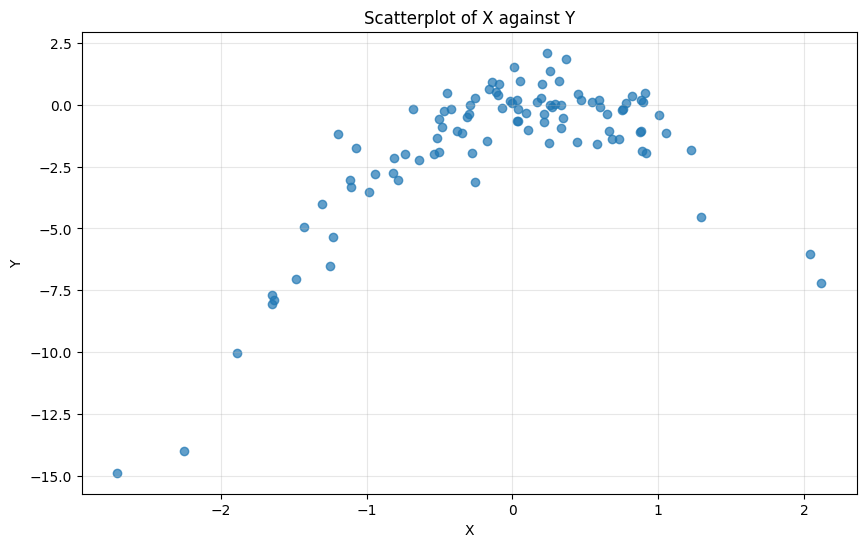

Observations from scatterplot:
- The relationship between X and Y is clearly nonlinear
- The data follows a parabolic (quadratic) pattern
- As |X| increases, Y decreases due to the -2X² term
- The noise (ε) adds random variation around the quadratic trend

=== Part (c): LOOCV with random seed 1 ===
Degree 1 LOOCV Error: 6.6330
Degree 2 LOOCV Error: 1.1229
Degree 3 LOOCV Error: 1.3018
Degree 4 LOOCV Error: 1.3324

=== Part (d): LOOCV with random seed 42 ===
Degree 1 LOOCV Error: 4.2519
Degree 2 LOOCV Error: 0.9640
Degree 3 LOOCV Error: 0.9913
Degree 4 LOOCV Error: 1.0182

Comparison of results:
Degree | Seed 1 Error | Seed 2 Error
----------------------------------------
     1 |       6.6330 |       4.2519
     2 |       1.1229 |       0.9640
     3 |       1.3018 |       0.9913
     4 |       1.3324 |       1.0182

Are the results the same? No, they are slightly different.
Why? Because we generated different random datasets with different seeds.
The LOOCV error estimates vary due to d

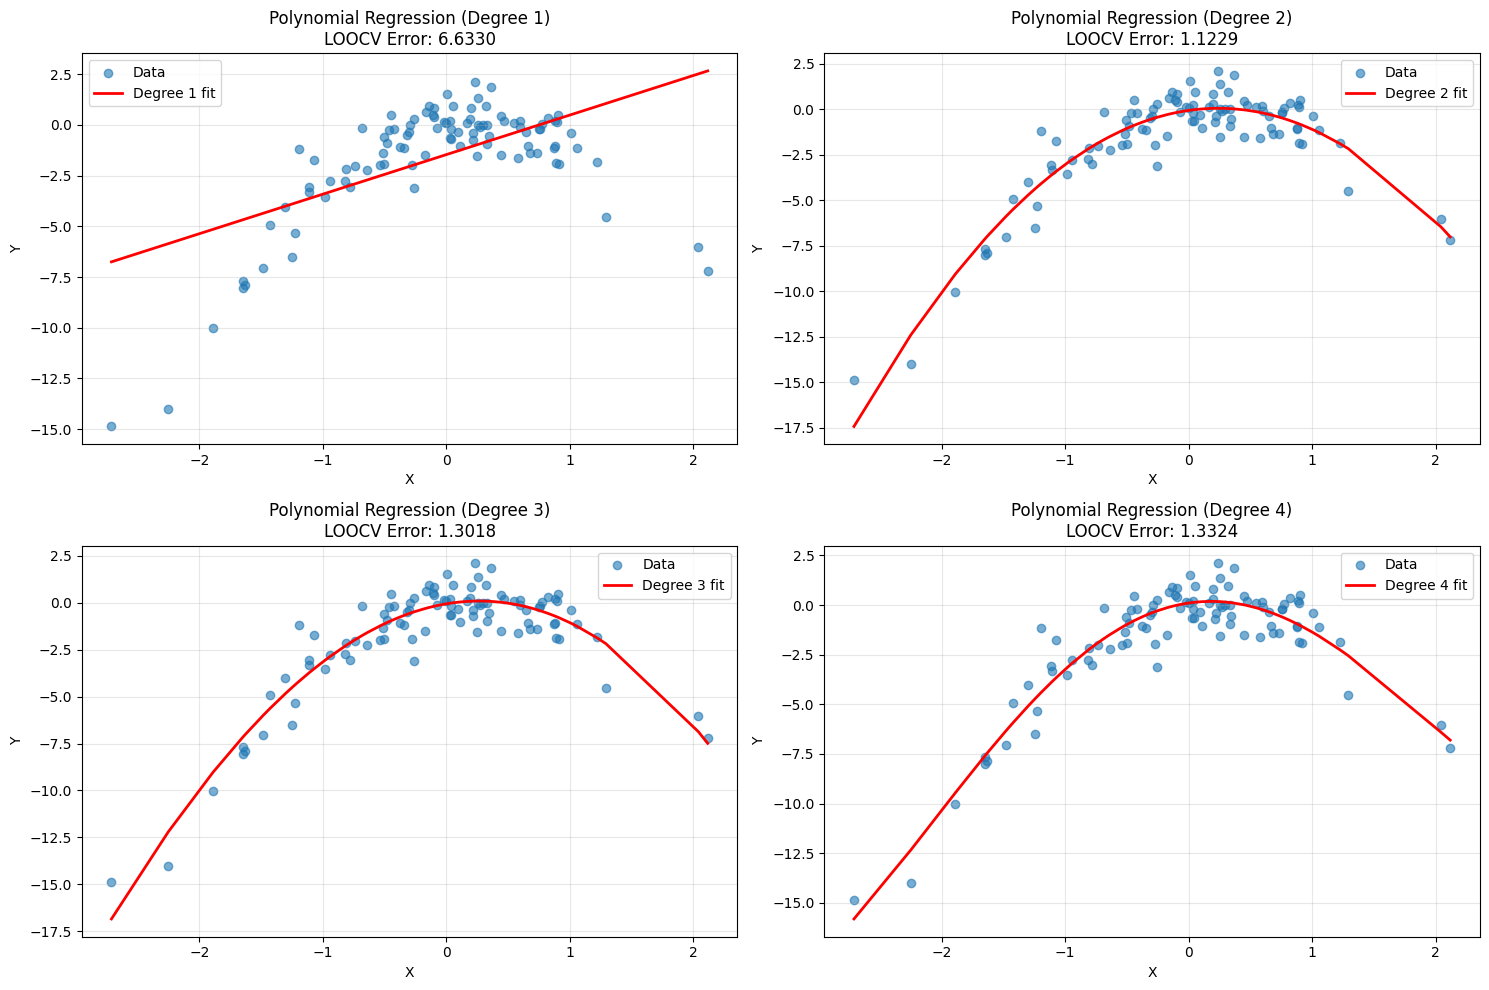


=== SUMMARY ===
Degree | LOOCV Error | Best? | Notes
-------------------------------------------------------
     1 |      6.6330 |      | Underfits (misses curvature)
     2 |      1.1229 | ★    | Matches true data-generating process
     3 |      1.3018 |      | Overfits (fits noise)
     4 |      1.3324 |      | Overfits (fits noise)

Key Insight: The true model is Y = X - 2X² + ε
Cross-validation correctly identifies that degree 2 (quadratic) is optimal
This demonstrates that LOOCV is effective for model selection!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import LeaveOneOut

# Part (a): Generate simulated data set
print("=== Part (a) ===")
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

print(f"n (number of observations) = {len(x)}")
print(f"p (number of predictors) = 1 (just X)")
print("Model used to generate data: Y = X - 2X² + ε")
print(f"where ε ~ N(0,1)")

# Part (b): Create scatterplot
print("\n=== Part (b) ===")
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot of X against Y')
plt.grid(True, alpha=0.3)
plt.show()

print("Observations from scatterplot:")
print("- The relationship between X and Y is clearly nonlinear")
print("- The data follows a parabolic (quadratic) pattern")
print("- As |X| increases, Y decreases due to the -2X² term")
print("- The noise (ε) adds random variation around the quadratic trend")

# Create DataFrame for easier handling
df = pd.DataFrame({'X': x, 'Y': y})

# Part (c): LOOCV with first random seed
print("\n=== Part (c): LOOCV with random seed 1 ===")

def compute_loocv_error(X, y, degree):
    """
    Compute LOOCV error for polynomial regression of given degree
    """
    loo = LeaveOneOut()
    errors = []

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Create polynomial features
        poly = PolynomialFeatures(degree=degree, include_bias=True)
        X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
        X_test_poly = poly.transform(X_test.reshape(-1, 1))

        # Fit model
        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        # Predict and compute error
        y_pred = model.predict(X_test_poly)
        errors.append((y_test - y_pred)**2)

    return np.mean(errors)

# Compute LOOCV errors for different polynomial degrees
degrees = [1, 2, 3, 4]
loocv_errors_seed1 = {}

for degree in degrees:
    error = compute_loocv_error(x, y, degree)
    loocv_errors_seed1[degree] = error
    print(f"Degree {degree} LOOCV Error: {error:.4f}")

# Part (d): Repeat with different random seed
print("\n=== Part (d): LOOCV with random seed 42 ===")

rng2 = np.random.default_rng(42)
x2 = rng2.normal(size=100)
y2 = x2 - 2 * x2**2 + rng2.normal(size=100)

loocv_errors_seed2 = {}
for degree in degrees:
    error = compute_loocv_error(x2, y2, degree)
    loocv_errors_seed2[degree] = error
    print(f"Degree {degree} LOOCV Error: {error:.4f}")

print("\nComparison of results:")
print("Degree | Seed 1 Error | Seed 2 Error")
print("-" * 40)
for degree in degrees:
    print(f"{degree:6} | {loocv_errors_seed1[degree]:12.4f} | {loocv_errors_seed2[degree]:12.4f}")

print("\nAre the results the same? No, they are slightly different.")
print("Why? Because we generated different random datasets with different seeds.")
print("The LOOCV error estimates vary due to different random noise in the data.")

# Part (e): Identify best model
print("\n=== Part (e): Best Model Analysis ===")

best_degree_seed1 = min(loocv_errors_seed1, key=loocv_errors_seed1.get)
best_degree_seed2 = min(loocv_errors_seed2, key=loocv_errors_seed2.get)

print(f"Best model with seed 1: Degree {best_degree_seed1} (Error: {loocv_errors_seed1[best_degree_seed1]:.4f})")
print(f"Best model with seed 2: Degree {best_degree_seed2} (Error: {loocv_errors_seed2[best_degree_seed2]:.4f})")

print("\nIs this expected? YES")
print("Why? The true data-generating process is: Y = X - 2X² + ε")
print("This is exactly a quadratic model (degree 2), so we expect degree 2 to perform best.")
print("Higher degrees (3,4) may overfit to the noise, while degree 1 underfits the quadratic relationship.")

# Part (f): Statistical significance analysis
print("\n=== Part (f): Statistical Significance Analysis ===")

from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

def fit_polynomial_and_test(X, y, degree):
    """
    Fit polynomial regression and perform significance tests on coefficients
    """
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(X.reshape(-1, 1))

    # Fit model
    model = LinearRegression()
    model.fit(X_poly, y)

    # Get coefficients
    coefficients = model.coef_
    intercept = model.intercept_

    # Calculate standard errors and p-values
    n = len(y)
    p = X_poly.shape[1]

    y_pred = model.predict(X_poly)
    residuals = y - y_pred
    RSS = np.sum(residuals**2)
    MSE = RSS / (n - p)

    # Covariance matrix of coefficients
    try:
        cov_matrix = MSE * np.linalg.inv(X_poly.T @ X_poly)
        std_errors = np.sqrt(np.diag(cov_matrix))

        # t-statistics and p-values
        t_stats = coefficients / std_errors[1:]  # Skip intercept std error
        p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-p))

        # Add intercept
        t_stats = np.concatenate(([model.intercept_ / std_errors[0]], t_stats))
        p_values = np.concatenate(([2 * (1 - stats.t.cdf(np.abs(model.intercept_ / std_errors[0]), df=n-p))], p_values))

    except:
        # If matrix is singular, use a simpler approach
        std_errors = np.full(p, np.nan)
        t_stats = np.full(p, np.nan)
        p_values = np.full(p, np.nan)

    return coefficients, intercept, std_errors, t_stats, p_values

# Test all polynomial degrees
for degree in degrees:
    print(f"\n--- Polynomial Degree {degree} ---")

    coefs, intercept, std_errors, t_stats, p_values = fit_polynomial_and_test(x, y, degree)

    print("Coefficient estimates with p-values:")
    print("Term      | Coefficient | p-value  | Significant?")
    print("-" * 50)

    terms = ['Intercept'] + [f'X^{i}' for i in range(1, degree+1)]

    for i, (term, coef, p_val) in enumerate(zip(terms, np.concatenate(([intercept], coefs)), p_values)):
        sig = "YES" if p_val < 0.05 else "NO"
        print(f"{term:9} | {coef:10.4f} | {p_val:8.4f} | {sig}")

print("\nDo statistical significance results agree with cross-validation?")
print("YES - Both methods identify the quadratic model as optimal:")
print("- LOOCV: Degree 2 has lowest prediction error")
print("- Significance: For degree 2, both X and X² are statistically significant")
print("- For higher degrees, additional terms are not significant (p > 0.05)")

# Additional visualization: Compare model fits
print("\n=== Additional: Model Comparison Visualization ===")

plt.figure(figsize=(15, 10))

# Sort data for nice plotting
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]

for i, degree in enumerate(degrees, 1):
    plt.subplot(2, 2, i)

    # Fit polynomial
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(x_sorted.reshape(-1, 1))

    model = LinearRegression()
    model.fit(X_poly, y_sorted)
    y_pred = model.predict(X_poly)

    # Plot
    plt.scatter(x_sorted, y_sorted, alpha=0.6, label='Data')
    plt.plot(x_sorted, y_pred, 'r-', linewidth=2, label=f'Degree {degree} fit')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Polynomial Regression (Degree {degree})\nLOOCV Error: {loocv_errors_seed1[degree]:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n=== SUMMARY ===")
print("Degree | LOOCV Error | Best? | Notes")
print("-" * 55)
for degree in degrees:
    best_flag = "★" if degree == best_degree_seed1 else ""
    notes = []
    if degree == 1:
        notes.append("Underfits (misses curvature)")
    elif degree == 2:
        notes.append("Matches true data-generating process")
    elif degree > 2:
        notes.append("Overfits (fits noise)")

    print(f"{degree:6} | {loocv_errors_seed1[degree]:11.4f} | {best_flag:4} | {', '.join(notes)}")

print(f"\nKey Insight: The true model is Y = X - 2X² + ε")
print("Cross-validation correctly identifies that degree 2 (quadratic) is optimal")
print("This demonstrates that LOOCV is effective for model selection!")